Seuil (réussite) = 50
Nombre d'étudiants : 30
Réussis  (1) : 25
Échoués  (0) : 5

Exemple de données (3 premières lignes) :
[[2 0]
 [3 0]
 [4 0]]

--- Résultats KNN (K = 3) ---
Bonnes prédictions = 30 / 30
Précision          = 100.0 %



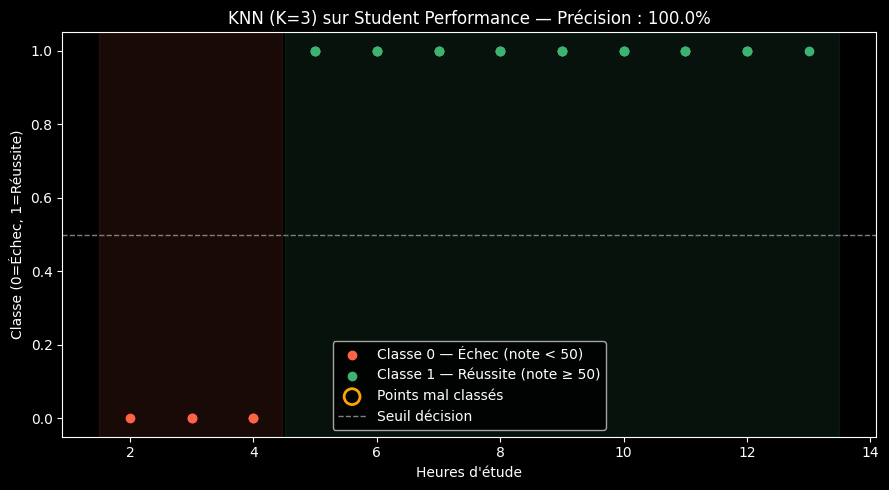

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#KNN
# ------------------------------------------------------------
# Fonction : distance_euclidienne
# Objectif :
#   Calculer la distance entre deux points A et B
#
# Formule mathématique :
#   d(A, B) = sqrt( Σ (Ai - Bi)^2 )
#
# ------------------------------------------------------------
def distance_euclidienne(A, B):
    s = 0
    for i in range(len(A)):
        s = s + (B[i] - A[i])**2   # somme des carrés des différences
    return s**0.5                  # racine carrée


# ------------------------------------------------------------
# Fonction : obtenir_voisins
# Objectif :
#   Trouver les K points les plus proches d’un point x
# Étapes :
#   1. Calculer la distance entre x et tous les points
#   2. Trier ces distances
#   3. Garder les K plus petites
# ------------------------------------------------------------
def obtenir_voisins(Data, x, k):
    distances = []

    for d in Data:
        point  = d[:-1]   # variables explicatives (features)
        classe = d[-1]    # classe associée au point

        # Calcul de la distance entre point et x
        dist = distance_euclidienne(point, x)

        # Stockage : (distance, classe)
        distances.append((dist, classe))

    # Tri par distance croissante
    distances.sort(key=lambda element: element[0])

    # Sélection des K plus proches voisins
    k_plus_proches = distances[:k]

    return k_plus_proches


# ------------------------------------------------------------
# Fonction : classe_majoritaire
# Objectif :
#   Déterminer la classe la plus fréquente parmi les voisins
#
# Intuition :
#   Chaque voisin "vote" pour sa classe
#   La classe avec le plus de votes gagne
# ------------------------------------------------------------
def classe_majoritaire(KNN, nbr_classes):
    # Initialisation du compteur pour chaque classe
    LC = [0] * nbr_classes

    # Comptage des votes
    for v in KNN:
        LC[int(v[1])] += 1

    # Retourner l’indice de la classe dominante
    imax = LC.index(max(LC))
    return imax


# ------------------------------------------------------------
# Fonction : KNN_scratch
# Objectif :
#   Algorithme complet KNN :
#     → trouver les voisins
#     → faire le vote
#     → retourner la classe prédite
# ------------------------------------------------------------
def KNN_scratch(Data, x, k, nbr_classes):
    voisins = obtenir_voisins(Data, x, k)
    return classe_majoritaire(voisins, nbr_classes)

# -------------------------------------------------------
# 1. Chargement et préparation des données

df = pd.read_csv("student_performance.csv")

# Variable explicative : heures d'étude
X = df['Hours_Studied'].values

# Seuil de réussite : 50 points
seuil = 50

# Transformation en classification :
#   0 → note < 50  (échec)
#   1 → note >= 50 (réussite)
y = (df['Performance_Index'].values >= seuil).astype(int)

print("Seuil (réussite) =", seuil)
print("Nombre d'étudiants :", len(y))
print("Réussis  (1) :", np.sum(y == 1))
print("Échoués  (0) :", np.sum(y == 0))
print()

# ============================================================
# 2. Construction du dataset pour KNN
# ============================================================

# Format : [heures_étude, classe]
Data = np.column_stack((X, y))

print("Exemple de données (3 premières lignes) :")
print(Data[:3])
print()

# ============================================================
# 3. Prédiction avec KNN
# ============================================================

K = 3  # nombre de voisins
NBR_CLASSES = 2  # classes : 0 et 1

y_pred = []

for heures in X:
    pred = KNN_scratch(Data, [heures], K, NBR_CLASSES)
    y_pred.append(pred)

y_pred = np.array(y_pred)

# ============================================================
# 4. Évaluation du modèle
# ============================================================

bonnes = np.sum(y_pred == y)
precision = bonnes / len(y) * 100

print(f"--- Résultats KNN (K = {K}) ---")
print(f"Bonnes prédictions = {bonnes} / {len(y)}")
print(f"Précision          = {round(precision, 2)} %")
print()

# ============================================================
# 5. Visualisation des résultats

x_grille = np.linspace(X.min() - 0.5, X.max() + 0.5, 300)

y_grille = np.array([
    KNN_scratch(Data, [x], K, NBR_CLASSES)
    for x in x_grille
])

plt.figure(figsize=(9, 5))

# Zones de décision
plt.fill_between(
    x_grille, 0, 1,
    where=(y_grille == 0),
    alpha=0.1,
    color='tomato',
    transform=plt.gca().get_xaxis_transform()
)
plt.fill_between(
    x_grille, 0, 1,
    where=(y_grille == 1),
    alpha=0.1,
    color='mediumseagreen',
    transform=plt.gca().get_xaxis_transform()
)

# Points réels
plt.scatter(
    X[y == 0], y[y == 0],
    color='tomato',
    label='Classe 0 — Échec (note < 50)',
    zorder=3
)
plt.scatter(
    X[y == 1], y[y == 1],
    color='mediumseagreen',
    label='Classe 1 — Réussite (note ≥ 50)',
    zorder=3
)

# Points mal classés
mal_classes = (y_pred != y)
plt.scatter(
    X[mal_classes], y[mal_classes],
    color='none',
    edgecolors='orange',
    s=130,
    linewidths=2,
    label='Points mal classés',
    zorder=4
)

# Ligne seuil de décision
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Seuil décision')

plt.title(f'KNN (K={K}) sur Student Performance — Précision : {round(precision, 1)}%')
plt.xlabel("Heures d'étude")
plt.ylabel('Classe (0=Échec, 1=Réussite)')
plt.legend()
plt.tight_layout()
plt.show()